In [1]:
from chime.calibration import load_Learmonth_data
import numpy as np
import matplotlib.pyplot as plt
import chime
from scipy.optimize import curve_fit

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_016"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

In [2]:

df = load_Learmonth_data("/home/scratch/dbautist/CHIME_archive/learmonthData/L240116.SRD")
df


,time,seconds,245,410,610,1415,2695,4975,8800,15400
0,2024-01-16 00:00:00+00:00,0.0,18.0,35.0,58.0,NaN,NaN,NaN,NaN,NaN
1,2024-01-16 00:00:01+00:00,1.0,18.0,35.0,59.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-16 00:00:02+00:00,2.0,20.0,35.0,59.0,NaN,NaN,NaN,NaN,NaN
3,2024-01-16 00:00:03+00:00,3.0,19.0,35.0,59.0,NaN,NaN,NaN,NaN,NaN
4,2024-01-16 00:00:04+00:00,4.0,19.0,35.0,60.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
86395,2024-01-16 23:59:55+00:00,86395.0,26.0,38.0,85.0,NaN,NaN,NaN,NaN,NaN
86396,2024-01-16 23:59:56+00:00,86396.0,29.0,38.0,86.0,NaN,NaN,NaN,NaN,NaN
86397,2024-01-16 23:59:57+00:00,86397.0,28.0,38.0,86.0,NaN,NaN,NaN,NaN,NaN
86398,2024-01-16 23:59:58+00:00,86398.0,27.0,38.0,86.0,NaN,NaN,NaN,NaN,NaN


0        350000.0
1        350000.0
2        350000.0
3        350000.0
4        350000.0
           ...   
86395    380000.0
86396    380000.0
86397    380000.0
86398    380000.0
86399    380000.0
Name: 410, Length: 86400, dtype: float32


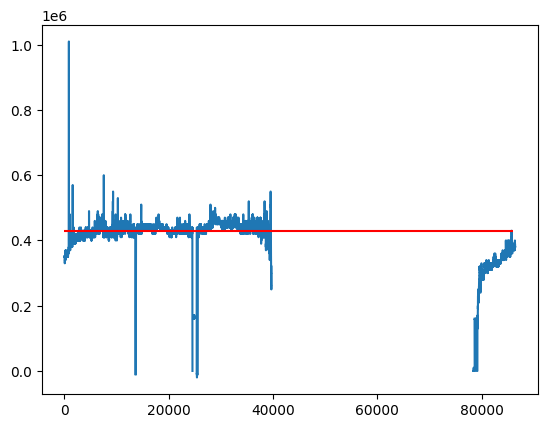

In [4]:
plt.figure()


Jy = df["410"] * 10000 
freq_dfmid = np.nanmedian(Jy)

plt.plot(df["seconds"], Jy)

print(Jy)

plt.hlines(freq_dfmid, xmin=0, xmax=86000, color='red')

In [5]:
median = np.nanmedian(df["410"])
print(median)

43.0


[8.30077013e+06 1.93093300e+03 1.75329315e+01 1.37879501e+07]
errors:[3.52184759e+05 5.98147985e-01 8.84562596e-01 8.65796209e+04]
fit paramenters:[8.30077013e+06 1.93093300e+03 1.75329315e+01 1.37879501e+07]


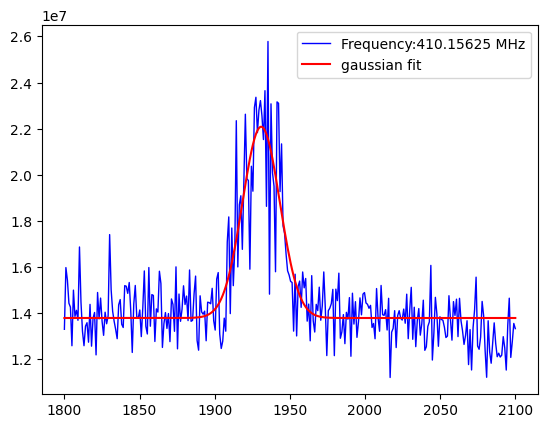

In [6]:
start = 1800
stop = 2100
#user input:

freq_index = 25

y = chime_data[start:stop, freq_index]
x = np.linspace(start, stop, num=len(y))

#y = the chime data at indicies 
#x= line spacing

#plt.figure()
#plt.plot(x, y)

plt.figure()
def gaus_CHIME410(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

plt.plot(x, y, color="blue", linewidth=1, label=f"Frequency:{frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)

#parameter guesses:

p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME410, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

#y_fit = def with the initial guesses for data uncalibrated
y_fit = gaus_CHIME410(x, popt[0], popt[1], popt[2], popt[3])

plt.plot(x, y_fit, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')


430000.0
[ 1.51886432e+05  1.93093300e+03 -1.75329315e+01  2.52290151e+05]
fit paramenters:[8.30077013e+06 1.93093300e+03 1.75329315e+01 1.37879501e+07]


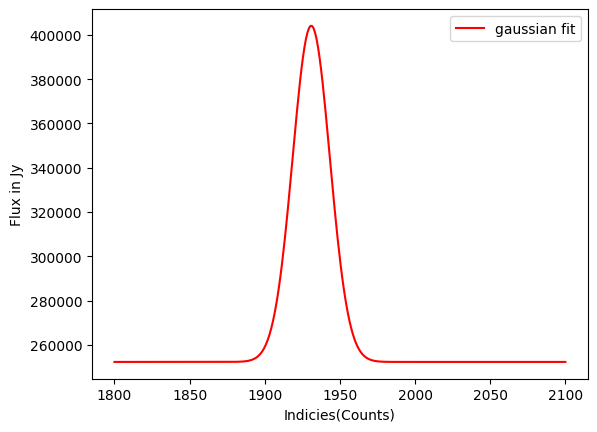

In [7]:
#calibration:

def Jansky_CHIME_Fit(x, a, CHIME_mid_Jy, CHIME_std_Jy, d):
    return a * np.exp(-(x-CHIME_mid_Jy)**2/(CHIME_std_Jy)**2)+d

a = popt[0]
df["410"] 
mid_flux = np.nanmedian(df["410"] * 10000)
print(mid_flux)

#Fit_Jy = chime data multiplied by the flux divided by a
converted_y = y_fit * (mid_flux/23500000)  #31 is the average solar flux value for 410 MHz (34 is the median)
#converted_y?
y = chime_data[start:stop, freq_index]

p0 = (280000, 1925, 75, 180000)
popt_raw, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_y, p0=p0)
print(popt_raw)

a = popt_raw[0]

#plotting the fitted Jy

plt.plot(x, converted_y, color='red', label='gaussian fit')
plt.ylabel("Flux in Jy")
plt.xlabel('Indicies(Counts)')
plt.legend()
print(f'fit paramenters:{popt}')


[ 1.51886432e+05  1.93093300e+03 -1.75329315e+01  2.52290151e+05]
errors:[9.71064658e-10 9.01312133e-14 1.33289130e-13 2.38719882e-10]
fit paramenters:[8.30077013e+06 1.93093300e+03 1.75329315e+01 1.37879501e+07]


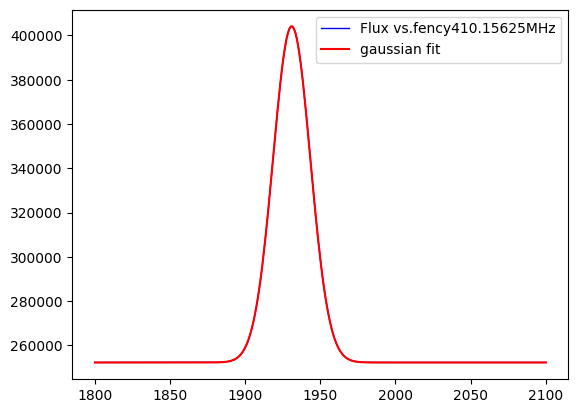

In [8]:
#Raw data(converted to Janskys):



y = chime_data[start:stop, freq_index]
CHIME_mid = np.median(converted_y)
CHIME_std = np.std(converted_y)

converted_raw_y = y * (mid_flux/a)

def Jansky_CHIME_Fit(x, a, CHIME_mid, CHIME_std, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_std)**2)+d


plt.plot(x, converted_y, color='blue', linewidth=1, label=f"Flux vs.fency{frequency[freq_index]}MHz")

#parameter guesses:

p0 = (280000, 1925, 75, 180000)

#fitting:

popt_raw, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_y, p0=p0)
print(popt_raw)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = Jansky_CHIME_Fit(x, popt_raw[0], popt_raw[1], popt_raw[2], popt_raw[3])

plt.plot(x, y_fit_Jy, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')


# Graph of conversions:

values:

the function gaus_CHIME410 puts in the conversion formula to then be used in the gaussian fit.  p0 puts values into the empty arguements where they are then given values to in popt and popt_Jy.  popt 0 through 3 are amplitude, the median of the data, the standard deviation of the data, and the estimated scaling factor. 

y is the CHIME data to a frequency of 410MHz

x are the line indicies dependent on y to scaling purposes

y_fit is the data for gaussian fit before the Janksy conversion

converted_raw_y is the raw data(not fitted to a gaussian) converted into units of Janskys

converted_y is the data converted into Janskys but fitted to a gaussian.

I use the function defined above to plot all the graphs depending on their estimation value and the formula for conversion all at 410MHz.

[8.30077013e+06 1.93093300e+03 1.75329315e+01 1.37879501e+07]
errors:[3.52184759e+05 5.98147985e-01 8.84562596e-01 8.65796209e+04]
amp:8300770.127961014
[4.30000420e+05 1.93093299e+03 1.75328901e+01 7.14249276e+05]
errors:[1.82435347e+04 5.98179368e-01 8.84611715e-01 4.48506913e+03]
amplitude:430000.4203676597


Text(0.5, 1.0, 'Flux vs. Time in Units of Janskys')

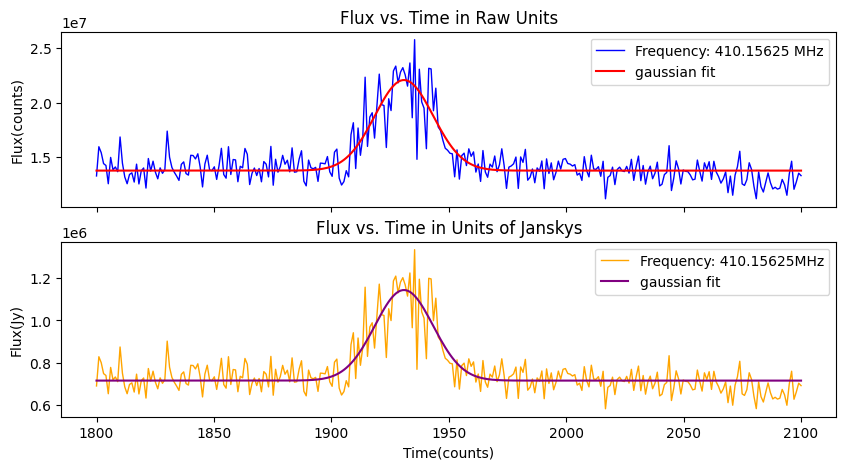

In [9]:
#Combining the two different plots:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,5), sharex='col') #for multiple graphs to exist

def gaus_CHIME410(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

ax1.plot(x, y, color="blue", linewidth=1, label=f"Frequency: {frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)
    
#Units are in counts:
p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME410, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

y_fit = gaus_CHIME410(x, popt[0], popt[1], popt[2], popt[3])
amp = popt[0]
print(f'amp:{amp}')

ax1.plot(x, y_fit, color='red', label='gaussian fit')
ax1.legend()
ax1.set_ylabel("Flux(counts)")
ax1.set_title("Flux vs. Time in Raw Units")


##############################################################################
#code for converted units to Janskys:

#parameter guesses(for calibrated data):

p0 = (280000, 1925, 50, 180000)

#calculations for converted y values

converted_y = y_fit * (mid_flux/amp)
converted_raw_y = y * (mid_flux/amp)
calibrated_CHIME_dat = chime_data * (mid_flux/amp)

#fitting:

popt_Jy, pcov = curve_fit(Jansky_CHIME_Fit, x, calibrated_CHIME_dat[start:stop, 25], p0=p0)
print(popt_Jy)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = gaus_CHIME410(x, popt_Jy[0], popt_Jy[1], popt_Jy[2], popt_Jy[3])
amp = popt_Jy[0]
print(f'amplitude:{amp}')

ax2.plot(x, converted_raw_y, color='orange', linewidth=1, label=f"Frequency: {frequency[freq_index]}MHz")
ax2.plot(x, y_fit_Jy, color='purple', label='gaussian fit')
ax2.legend()
ax2.set_xlabel("Time(counts)")
ax2.set_ylabel("Flux(Jy)")
ax2.set_title("Flux vs. Time in Units of Janskys")